#### Imports ####

In [1]:
import sys
from pathlib import Path
main_folder = str(Path.cwd().parent)
if main_folder not in sys.path:
    sys.path.append(main_folder)

import os
import time
import copy

import torch
import numpy as np
import hydra
import matplotlib
from matplotlib import pyplot as plt
from tqdm import tqdm

from plotter import Plotter, plot_score_field
from target import set_up_problem
from misc import convert_to_ranking
from diffusion import EDM
import phema #EDM type EMA
from likelihood import loglik
from model import EDMToyModel
from tempfield_demo import TemperingField

#### Load config file to set-up experiment and algorithm details ####

In [2]:
with hydra.initialize(version_base=None, config_path="../conf"):
   cfg = hydra.compose(config_name="demo", overrides=["+db=mysql"])
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_folder = os.path.join(project_root, 'temporary_outputs')
os.makedirs(output_folder, exist_ok=True)
if not cfg.plot.showduringtraining: # Show plots?
    matplotlib.use('Agg')

#### Device and Precision ####

In [3]:
torch.set_default_dtype(torch.float64 if cfg.device.precision_double else torch.float32)
device = torch.device(cfg.device.device)

#### Random seeds ####

In [4]:
import random
torch.manual_seed(cfg.exp.seed)
np.random.seed(cfg.exp.seed)
random.seed(cfg.exp.seed)

  #### Target belief density ####

In [5]:
target_name = cfg.exp.target #only works: 'twomoons','onemoon','ring'
D = 2
target, bounds, uniform, D, normalize = set_up_problem(target_name,D)
volX = np.prod([abs(x[1]-x[0]) for x in bounds])

#### Data generation 1/2 ####

In [6]:
target_sample = target.sample(10000)
target_mean = target_sample.mean(dim=0)
target_std = target_sample.std(dim=0)
def sample_alternatives(n,k=2,distribution="uniform"):
        if distribution=="uniform":
            return uniform.sample(torch.tensor([k*n])).to(device)
        elif distribution=="target":
            return target.sample(k*n).to(device)
        elif distribution=="mixture_gaussian":
            if target_name == "twomoons":
                target_mean1 = torch.tensor([-2.0,0.0])
                target_mean2 = torch.tensor([2.0,0.0])
                onemoon,_,_,_,_ = set_up_problem("onemoon",2)
                target_std = onemoon.sample(10000).std(dim=0)
                means = torch.stack([target_mean1, target_mean2])
                covariance_matrix = target_std * torch.eye(D).unsqueeze(0).repeat(2, 1, 1)
                component_distribution = torch.distributions.MultivariateNormal(means, covariance_matrix)
                mixing_probs = torch.tensor(cfg.exp.mixture_probs)
                mixing_distribution = torch.distributions.Categorical(mixing_probs)
                target_gaussian = torch.distributions.MixtureSameFamily(mixing_distribution, component_distribution)
            return target_gaussian.sample((k*n,))

def expert_feedback_ranking(alternatives,rum_noise_dist,s):
    k = alternatives.shape[0]
    if rum_noise_dist == "exponential":
        noise = torch.distributions.Exponential(s).sample((k,)).to(device)
    elif rum_noise_dist == "gumbel":
        noise = torch.distributions.Gumbel(torch.tensor([0.0]), torch.tensor([s])).sample((k,)).to(device).squeeze(1)
    logprobs = target.log_prob(alternatives).to(device) + noise
    _, ranking_inds = torch.sort(logprobs, descending=True)
    return ranking_inds.view(k).to(device)

def generate_dataset_ranking(n,k,distribution="uniform",rum_noise_dist="exponential",s=1.0):
    X = sample_alternatives(1,k,distribution)
    Y = expert_feedback_ranking(X,rum_noise_dist,s).view(1,k)
    X = X.unsqueeze(2) #add new dimension, which indicates sample index
    if n > 1:
        for i in range(0,n-1):
            alternatives = sample_alternatives(1,k,distribution)
            X = torch.cat((X,alternatives.unsqueeze(2)),2)
            Y = torch.cat((Y,expert_feedback_ranking(alternatives,rum_noise_dist,s).view(1,k)),0)
    Xdata = convert_to_ranking(X.numpy(),Y.numpy())
    #return X,Y #X.shape = (k,D,N) = (alternatives,space dimensions, number of rankings)
    return torch.from_numpy(Xdata).view(k,-1,n)

#### Data generation 2/2 ####

In [7]:
n = cfg.data.n
k = cfg.data.k
dataset = generate_dataset_ranking(n=n,k=k,distribution=cfg.exp.q_dist,rum_noise_dist=cfg.exp.rum_noise_dist,s=cfg.exp.s)
def minibatch(dataset,batch_size):
    indices = torch.randperm(n)[:batch_size]
    batch = dataset[:,:,indices]
    return batch

  #### Initialize the score-base model ####

In [8]:
sigma_data = target_std.mean()
if cfg.method.name == "EDM":
    if cfg.model.name == "EDMtoy":
        model = EDMToyModel(in_dim=D,num_layers=cfg.model.num_layers,hidden_dim=cfg.model.hidden_dim,sigma_data=sigma_data,use_temp=False).to(device).train().requires_grad_(True)
    sigma_min = cfg.method.sigma_min
    sigma_max = cfg.method.sigma_max
    sigma_intermediate = 0.2
    L = cfg.method.langevin_L
    #Noise schedule corresponding to the EDM time step discretization would be a natural option, but cosine noise schedule gives better results (and mode mixing?)
    def cosine_noise_schedule(sigma_min, sigma_max, L):
        t = torch.linspace(0, 1, steps=L)
        sigmas = sigma_min + 0.5*(sigma_max - sigma_min)*(1 + torch.cos(t * np.pi))
        return sigmas
    ALD_sigmas = cosine_noise_schedule(sigma_min, sigma_max, L)
    diffusion = EDM(D,sigma_min,sigma_max,ALD_sigmas=ALD_sigmas,L=L,joint_model=False)
    ema = copy.deepcopy(model).eval().requires_grad_(False)
    ema_std = cfg.method.ema_std

#### Initialize optimizer ####

In [9]:
loss_hist = np.array([])
batch_size = cfg.optimization.batch_size
optimizer = torch.optim.Adam(model.parameters(), betas=(0.9, 0.99))

#### Initialize plotter ####

In [10]:
plotter = Plotter(D,bounds)
xx,yy,zz = plotter.generate_grid(cfg)
def set_axes():
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.xlim(-3, 3)
    plt.ylim(-3, 3)

/Users/petrusmi/anaconda3/envs/torchcfm/lib/python3.10/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


### Main training loop: learn the marginal $p(\mathbf{x}_{winner})$ ###

  6%|▌         | 490/8192 [00:01<00:20, 384.32it/s]

500: loss 0.7001770 time 1.37


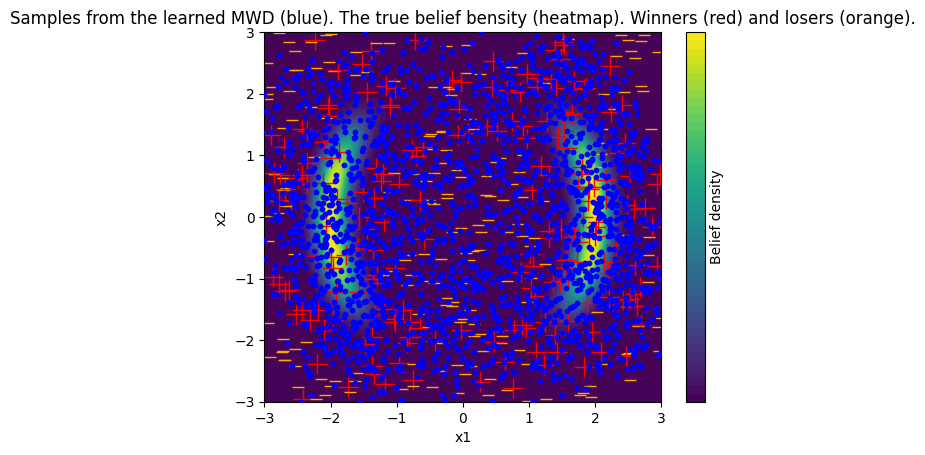

 12%|█▏        | 997/8192 [00:03<00:19, 375.22it/s]

1000: loss 0.7098141 time 1.86


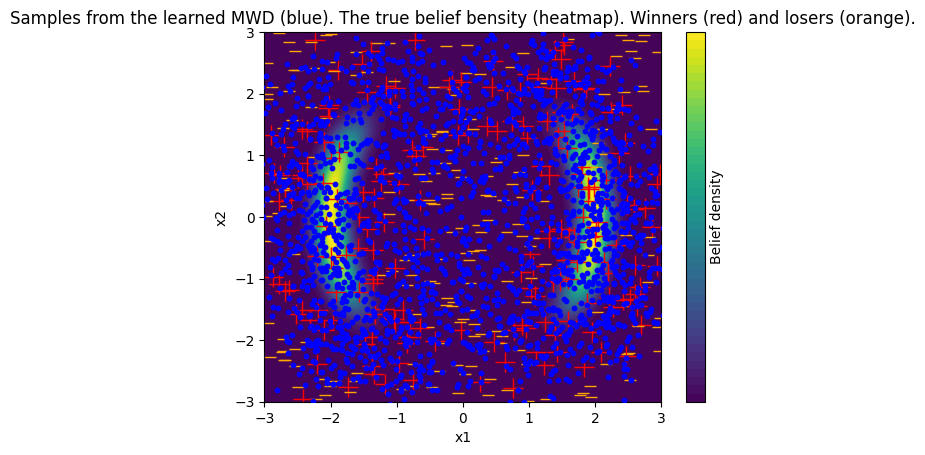

 18%|█▊        | 1466/8192 [00:04<00:18, 373.12it/s]

1500: loss 0.6961896 time 1.82


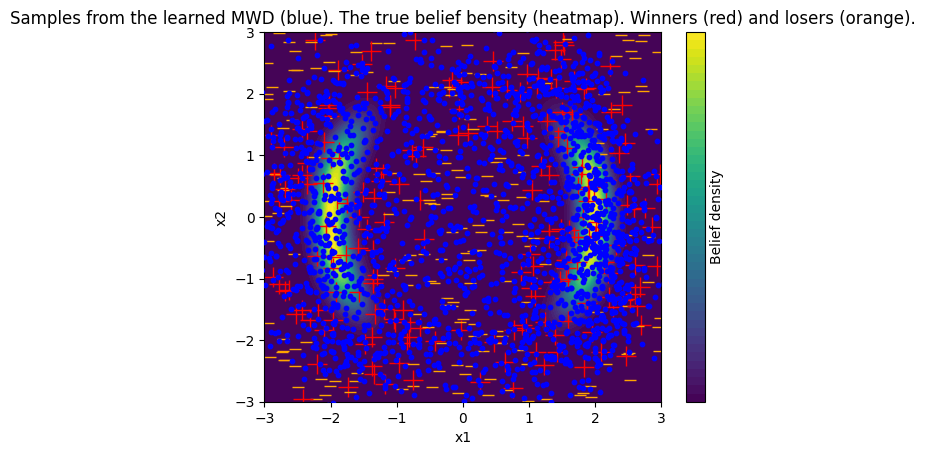

 24%|██▍       | 1975/8192 [00:06<00:16, 381.06it/s]

2000: loss 0.6691208 time 1.73


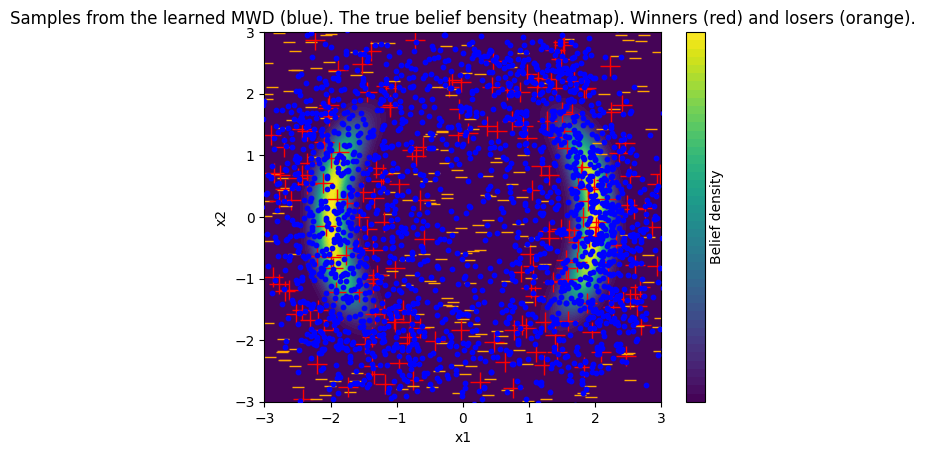

 30%|███       | 2485/8192 [00:08<00:15, 379.04it/s]

2500: loss 0.6845019 time 1.82


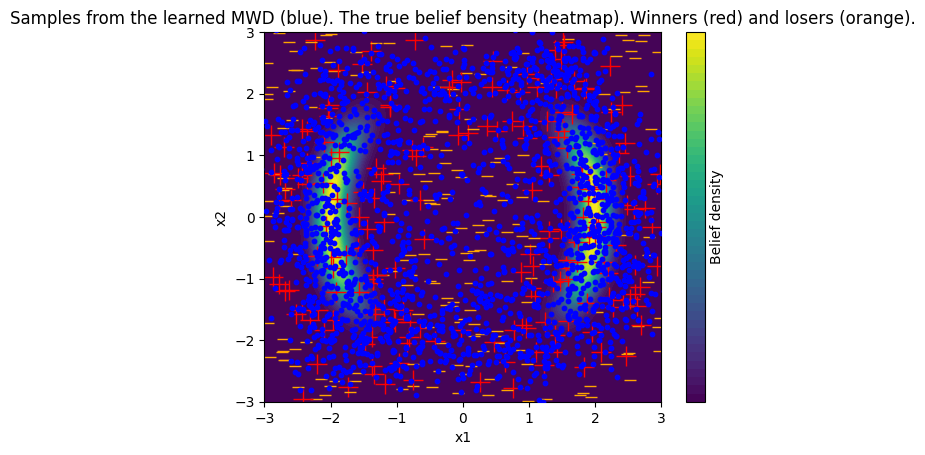

 37%|███▋      | 2993/8192 [00:10<00:13, 379.33it/s]

3000: loss 0.6895914 time 1.72


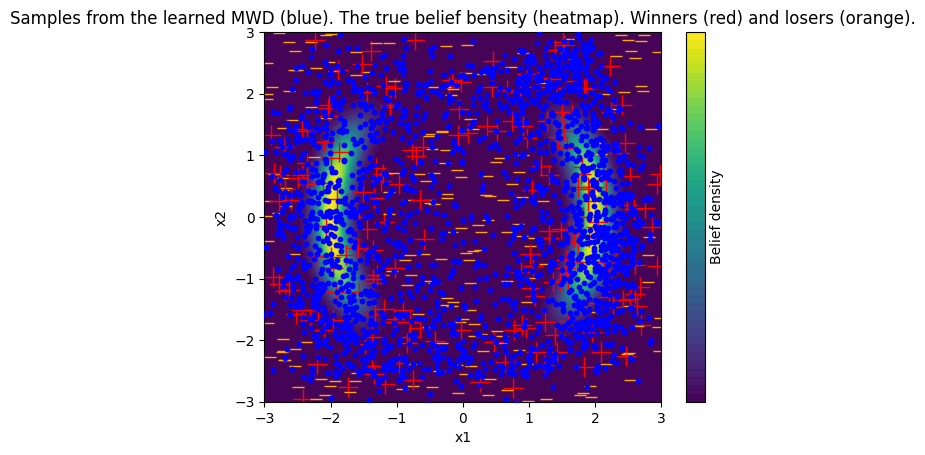

 43%|████▎     | 3498/8192 [00:12<00:12, 379.38it/s]

3500: loss 0.6695294 time 1.74


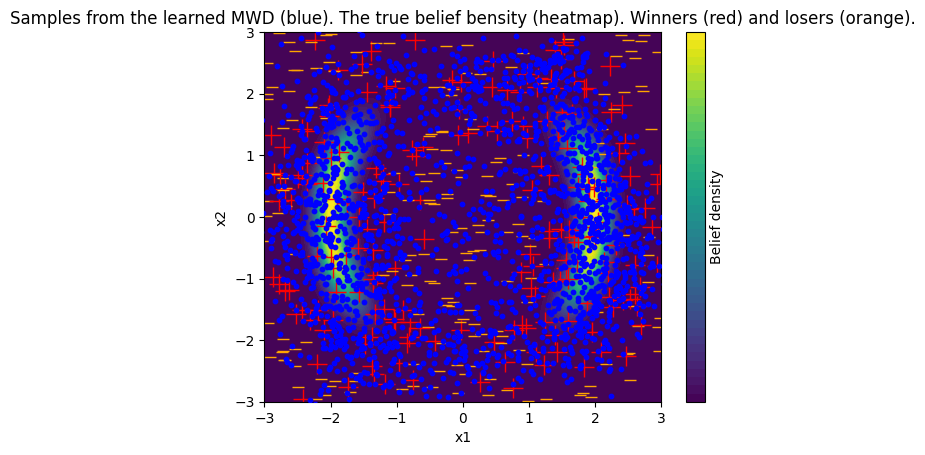

 48%|████▊     | 3963/8192 [00:13<00:11, 372.15it/s]

4000: loss 0.6738756 time 1.74


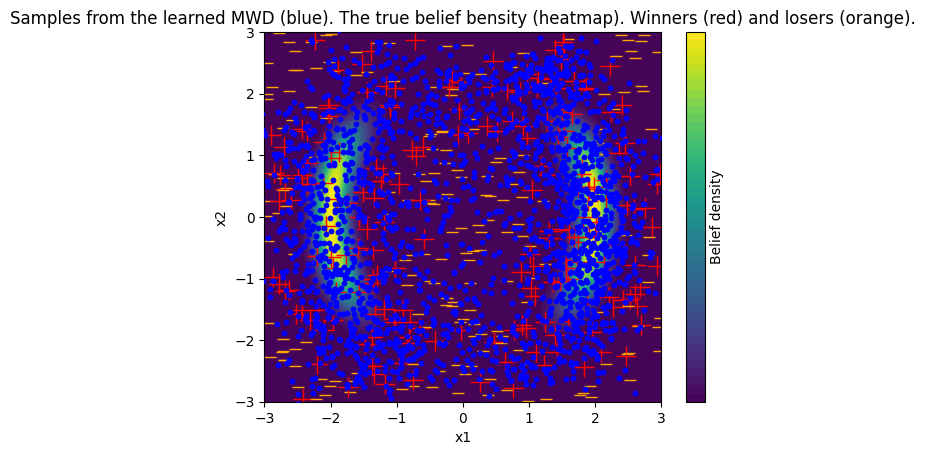

 55%|█████▍    | 4467/8192 [00:15<00:09, 374.28it/s]

4500: loss 0.6590093 time 1.87


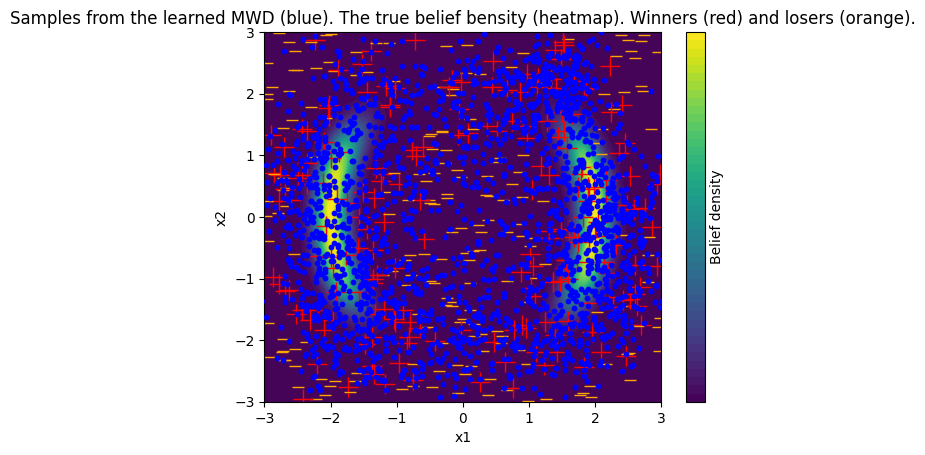

 61%|██████    | 4972/8192 [00:17<00:08, 378.87it/s]

5000: loss 0.6691211 time 1.74


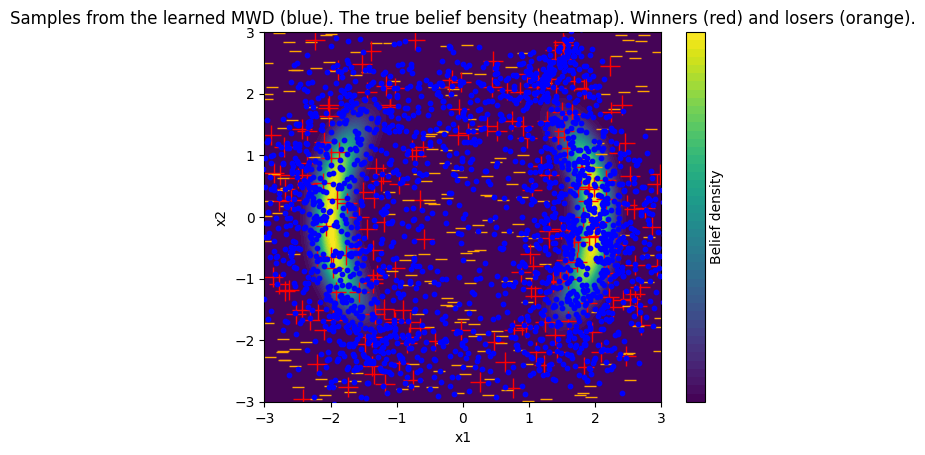

 67%|██████▋   | 5480/8192 [00:19<00:07, 380.52it/s]

5500: loss 0.6793865 time 1.73


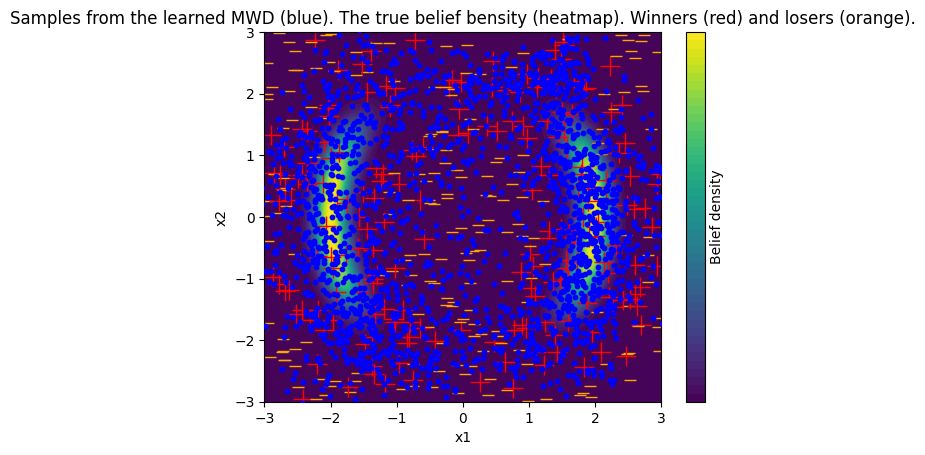

 73%|███████▎  | 5986/8192 [00:20<00:05, 371.28it/s]

6000: loss 0.6807839 time 1.84


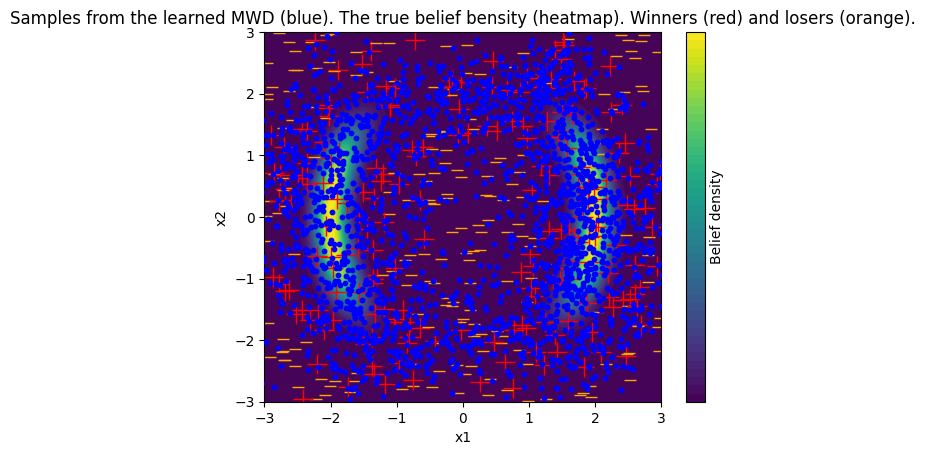

 79%|███████▉  | 6493/8192 [00:22<00:04, 378.74it/s]

6500: loss 0.6752087 time 1.74


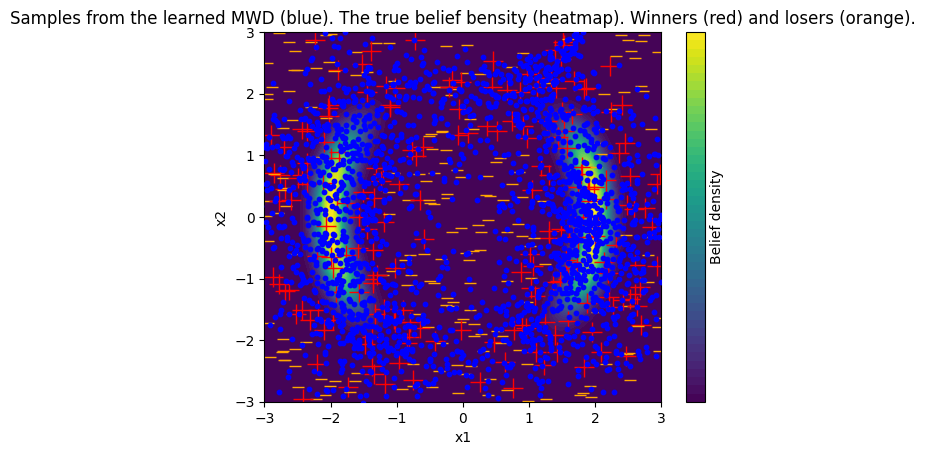

 85%|████████▌ | 6998/8192 [00:24<00:03, 377.30it/s]

7000: loss 0.6886209 time 1.74


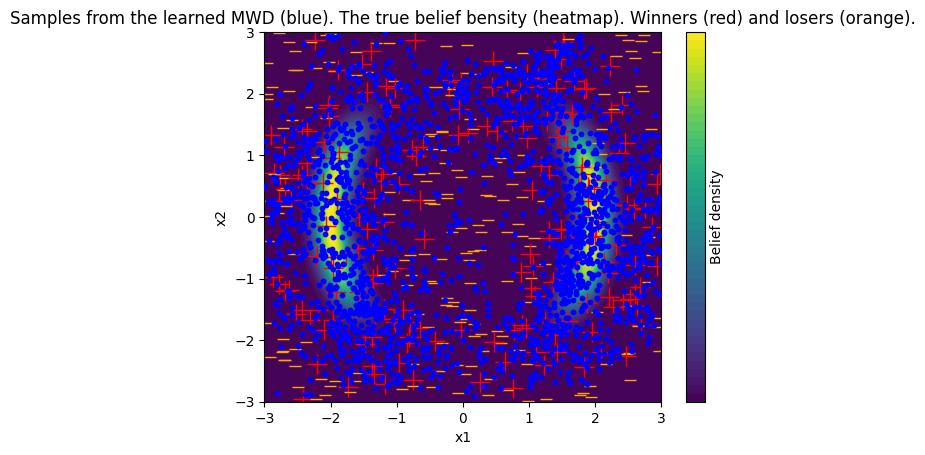

 91%|█████████ | 7465/8192 [00:26<00:01, 372.84it/s]

7500: loss 0.6562522 time 1.84


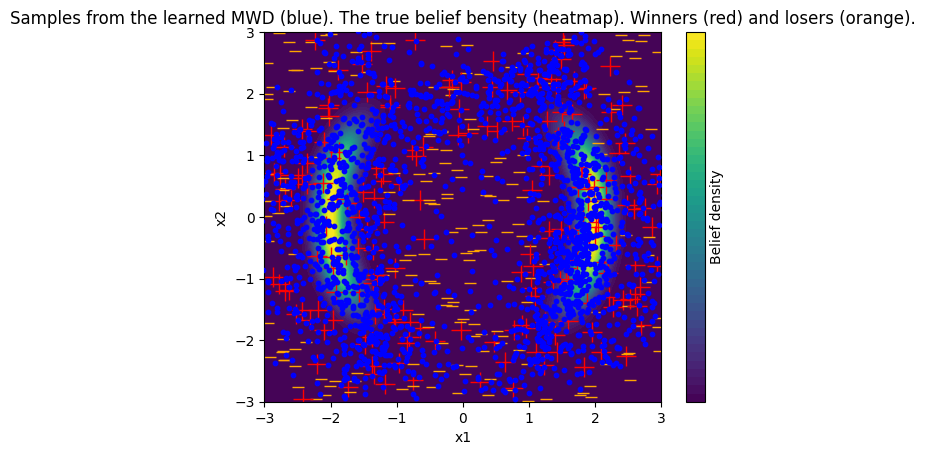

 97%|█████████▋| 7970/8192 [00:27<00:00, 376.92it/s]

8000: loss 0.6505863 time 1.74


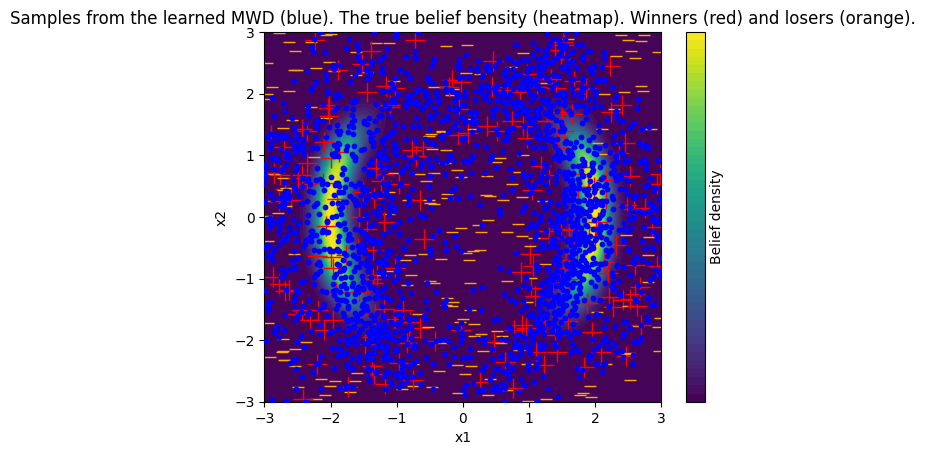

100%|██████████| 8192/8192 [00:28<00:00, 283.17it/s]


In [11]:
start = time.time()
for it in tqdm(range(cfg.optimization.max_iter),disable=not cfg.plot.progressbar_show):
    
    optimizer.param_groups[0]['lr'] = cfg.optimization.lr_ref / np.sqrt(max(it / cfg.optimization.lr_iter, 1)) #Below Eq. (15) in Karras et al, (NeurIPS2024)
    optimizer.zero_grad()

    batch = minibatch(dataset,batch_size) #(k, D, batch_size)
    winners =  batch.clone()[0,:,:].transpose(0,1) #(batch_size,D)
    #losers =  batch.clone()[1,:,:].transpose(0,1) #(batch_size,D) #Let's ignore the losers for now, i.e. consider marginal p(x_winner) instead of joint p(x_winner,x_loser)

    if cfg.method.name == "EDM":
    
        x0 = winners
        if cfg.method.sigma_dist=="uniform":
            log_sigma_t = torch.rand((batch_size,)) * (torch.tensor(sigma_max).log() - torch.tensor(sigma_min).log()) + torch.tensor(sigma_min).log()
        if cfg.method.sigma_dist=="lognormal":
            log_sigma_t = cfg.method.P_mean + cfg.method.P_std*torch.randn((batch_size,)) #Karras et al., 2024, Appendix C
        if random.random() < cfg.method.phi: #phi of time: specify first sigmas based on geometric series
            # Sample all from ALD_sigmas with or without replacement
            idx = torch.randperm(L)[:batch_size] if L >= batch_size else torch.randint(0, L, (batch_size,))
            log_sigma_t = ALD_sigmas.log()[idx]
        sigma_t = torch.clamp(log_sigma_t.exp().reshape(-1, 1), min=sigma_min, max=sigma_max)
        tilde_x = x0 + sigma_t * torch.randn_like(x0)
        temp = torch.zeros(batch_size,1) #i.e. no tempering
        joint = torch.zeros(batch_size,1) #joint=false, i.e. consider marginal p(x_winner)
        score = diffusion.score_function(tilde_x, x0, sigma_t)
        predicted_score = model(tilde_x, sigma_t, joint, temp)
        
        #Score-matching loss and weighting
        weight = (sigma_t**2) #Karras et al., 2024, Eq. (15)
        #weight = (sigma_t ** 2 + sigma_data ** 2) / (sigma_t * sigma_data) ** 2 #Karras et al., 2022, leads too high weights
        loss = torch.mean(weight * ((predicted_score - score) ** 2))
        
        if ~(torch.isnan(loss) | torch.isinf(loss)):
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            #Update EMA
            beta = phema.power_function_beta(std=ema_std, t_next=it+1, t_delta=1)
            for p_net, p_ema in zip(model.parameters(), ema.parameters()):
                p_ema.lerp_(p_net.detach(), 1 - beta)

            loss_hist = np.append(loss_hist, loss.to('cpu').detach().numpy())
        
    if (it + 1) % cfg.plot.show_iter == 0:
        end = time.time()
        mean_loss = np.mean(loss_hist[-cfg.plot.show_iter:])  # Compute mean of last cfg.plot.show_iter iters
        print(f"{it+1}: loss {mean_loss.item():0.7f} time {(end - start):0.2f}")
        start = end

        plotter.plot_target(target,xx,yy,zz)

        if cfg.method.name == "EDM":
            with torch.no_grad():
                sample_winner = diffusion.sample_deterministic(ema,cfg.plot.nsamples,joint=0.0).cpu().numpy()
            plt.scatter(sample_winner[:, 0], sample_winner[:, 1], color='blue', s=10, zorder=5)
            plotter.plot_data((minibatch(dataset,batch_size=n),torch.ones(n)))
            plt.title('Samples from the learned MWD (blue). The true belief bensity (heatmap). Winners (red) and losers (orange).')
        set_axes()
        plt.show()

#### Plot loss trajectory ####

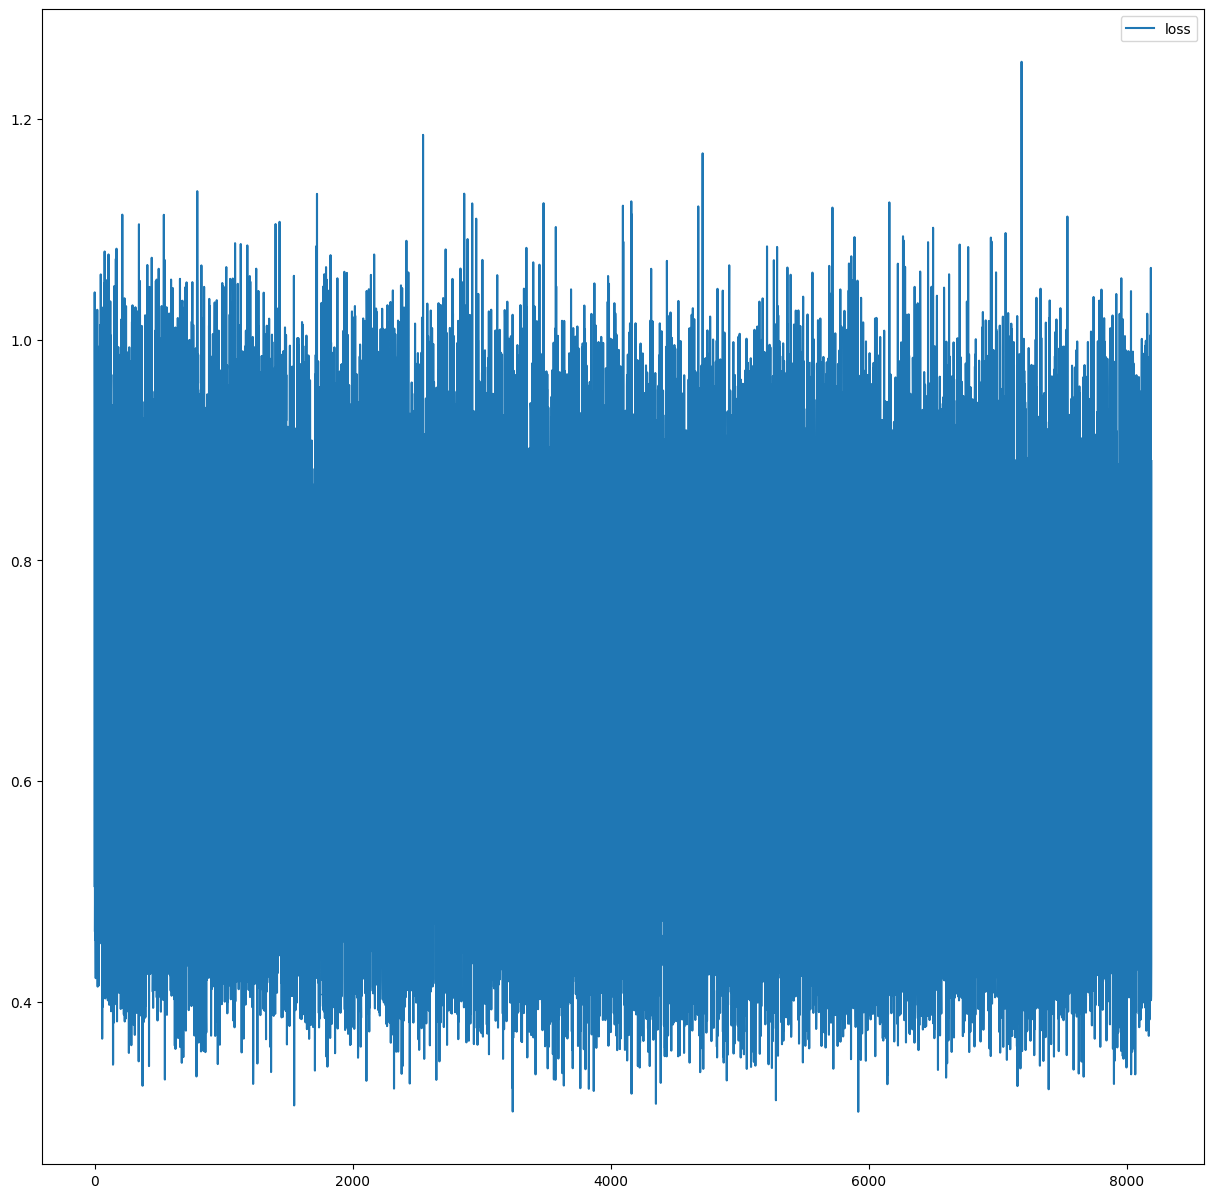

In [12]:
plt.figure(figsize=(15, 15))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

## Learn tempering field ##

In [13]:
tempfield = TemperingField(D=2,diffusion=diffusion,MWD=ema,minibatch=minibatch,loglik=loglik,s=cfg.exp.s,MWD_sample_size=2000*D,r_hidden_dim=64,quantile=0.999)
tempfield.initialize(dataset,batchsize=cfg.optimization.tau_batch_size,lr=cfg.optimization.tau_lr,maxiter=cfg.optimization.tau_max_iter,weight_decay=cfg.optimization.tau_max_weight_decay)

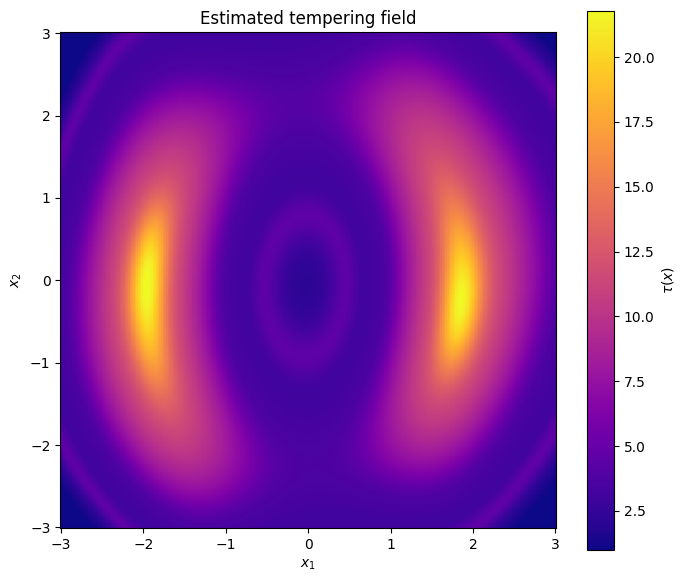

In [14]:
grid_size = 300

x_vals = torch.linspace(bounds[0][0], bounds[0][1], grid_size)
y_vals = torch.linspace(bounds[1][0], bounds[1][1], grid_size)
x_grid, y_grid = torch.meshgrid(x_vals, y_vals, indexing='ij')
grid_points = torch.stack([x_grid.flatten(), y_grid.flatten()], dim=1)

with torch.no_grad():
    z_grid = tempfield.tau(grid_points,clamp=True).reshape(grid_size, grid_size)

plt.figure(figsize=(8, 7))
plt.pcolormesh(x_grid, y_grid, z_grid, shading='auto', cmap='plasma')
plt.colorbar(label=r'$\tau(x)$')
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title('Estimated tempering field')
plt.show()


## Use score-scaled ALD to sample from the belief density ##

In [15]:
nsamples = D*2048
synthetic_data = {}
with torch.no_grad():
    #Speed and quality can be traded off by adjusting the number of Langevin steps and the step size
    epsilon = cfg.method.langevin_epsilon
    T = cfg.method.langevin_T
    synthetic_data[1] = diffusion.sample_annealed_langevin(ema, int(nsamples), joint=0, score_scaled=True, tempfield=tempfield, T=T, epsilon=epsilon)
    synthetic_data[0] = diffusion.sample_deterministic(ema,int(nsamples),joint=0.0)

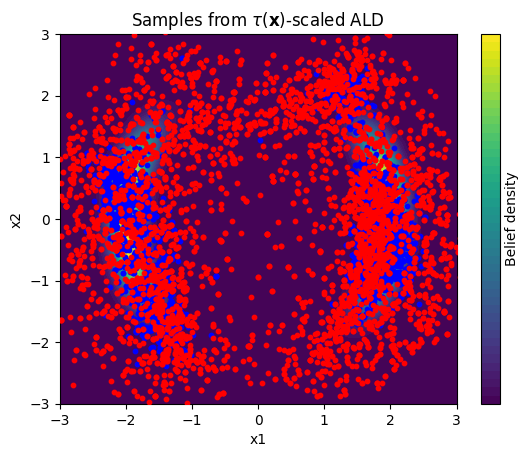

In [16]:
synthetic_keys = list(synthetic_data.keys())
plot_keys = [synthetic_keys[i] for i in [0,1]]
colors = ["blue","red"]
plotter.plot_target(target, xx, yy, zz)
for i, tau_key in enumerate(plot_keys):
    batch = synthetic_data[tau_key][torch.randint(0, synthetic_data[tau_key].shape[0], (nsamples,)), :]  # sample minibatch
    plt.scatter(batch[:, 0], batch[:, 1], color=colors[i], s=10, zorder=5)
plt.title(r'Samples from $\tau(\mathbf{x})$-scaled ALD') 
set_axes()
plt.show()

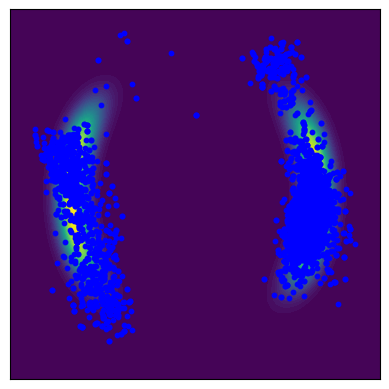

In [18]:
plotter.plot_target(target,xx,yy,zz,colorbar=False)
batch = synthetic_data[1][torch.randint(0, synthetic_data[1].shape[0], (nsamples,)), :] 
plt.scatter(batch[:, 0], batch[:, 1], color="blue", s=10, zorder=5)
plt.gca().set_aspect('equal', adjustable='box')
set_axes()
plt.xticks([])
plt.yticks([])
plt.xlabel("")
plt.ylabel("")
plt.show()